# **CSCE 5218 / CSCE 4930 Deep Learning**

# **The Perceptron** (20 pt)


In [15]:
instances_tr = read_data(r"C:\Users\santosh\OneDrive - UNT System\train.txt")
instances_te = read_data(r"C:\Users\santosh\OneDrive - UNT System\test_small.txt")

In [17]:
# Take a peek at the datasets
print(instances_tr[:5])
print(instances_te[:5])

[[-1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0], [-1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0], [-1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1], [-1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0], [-1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0]]
[[-1, 1, 1, 1, 1], [-1, 0, 0, 1, 1], [-1, 0, 1, 1, 0], [-1, 0, 1, 1, 0], [-1, 0, 1, 1, 0]]


### Build the Perceptron Model

You will need to complete some of the function definitions below.  DO NOT import any other libraries to complete this. 

In [71]:
import math
import itertools
import re


# Corpus reader, all columns but the last one are coordinates;
#   the last column is the label
def read_data(file_name):
    f = open(file_name, 'r')

    data = []
    # Discard header line
    f.readline()
    for instance in f.readlines():
        if not re.search('\t', instance): continue
        instance = list(map(int, instance.strip().split('\t')))
        # Add a dummy input so that w0 becomes the bias
        instance = [-1] + instance
        data += [instance]
    return data


def dot_product(array1, array2):
    #TODO: Return dot product of array 1 and array 2
    return sum(array1[i] * array2[i] for i in range(min(len(array1), len(array2)-1)))


def sigmoid(x):
    #TODO: Return outpout of sigmoid function on x
    return 1 / (1 + math.exp(-x))


# The output of the model, which for the perceptron is 
# the sigmoid function applied to the dot product of 
# the instance and the weights
def output(weight, instance):
    #TODO: return the output of the model 
    return sigmoid(dot_product(weight, instance))


# Predict the label of an instance; this is the definition of the perceptron
# you should output 1 if the output is >= 0.5 else output 0
def predict(weights, instance):
    #TODO: return the prediction of the model
    out = sigmoid(dot_product(weights, instance))
    
    if out >= 0.5:
        return 1
    else:
        return 0


# Accuracy = percent of correct predictions
def get_accuracy(weights, instances):
    # You do not to write code like this, but get used to it
    correct = sum([1 if predict(weights, instance) == instance[-1] else 0
                   for instance in instances])
    return correct * 100 / len(instances)


# Train a perceptron with instances and hyperparameters:
#       lr (learning rate) 
#       epochs
# The implementation comes from the definition of the perceptron
#
# Training consists on fitting the parameters which are the weights
# that's the only thing training is responsible to fit
# (recall that w0 is the bias, and w1..wn are the weights for each coordinate)
#
# Hyperparameters (lr and epochs) are given to the training algorithm
# We are updating weights in the opposite direction of the gradient of the error,
# so with a "decent" lr we are guaranteed to reduce the error after each iteration.
def train_perceptron(instances, lr, epochs):

    # weight initialization
    weights = [0] * (len(instances[0]) - 1)

    for _ in range(epochs):
        for instance in instances:

            # forward propagation
            in_value = dot_product(weights, instance)
            out = sigmoid(in_value)
            error = instance[-1] - out

            # backpropagation + gradient descent
            for i in range(len(weights)):
                weights[i] += lr * error * out * (1 - out) * instance[i]

    return weights

## Run it

In [72]:
instances_tr = read_data(r"C:\Users\santosh\OneDrive - UNT System\train.txt")
instances_te = read_data(r"C:\Users\santosh\OneDrive - UNT System\test_small.txt")

lr = 0.005
epochs = 5

weights = train_perceptron(instances_tr, lr, epochs)
accuracy = get_accuracy(weights, instances_te)

print(f"#tr: {len(instances_tr):3}, epochs: {epochs:3}, learning rate: {lr:.3f}; "
      f"Accuracy (test, {len(instances_te)} instances): {accuracy:.1f}")

#tr: 400, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4


## Questions

Answer the following questions. Include your implementation and the output for each question.



### Question 1

In `train_perceptron(instances, lr, epochs)`, we have the follosing code:
```
in_value = dot_product(weights, instance)
output = sigmoid(in_value)
error = instance[-1] - output
```

Why don't we have the following code snippet instead?
```
output = predict(weights, instance)
error = instance[-1] - output
```

#### TODO Add your answer here (text only)
The predict() function returns a discrete class label (either 0 or 1). During training, the perceptron needs the continuous output value from the sigmoid function, not the final class prediction.



### Question 2
Train the perceptron with the following hyperparameters and calculate the accuracy with the test dataset.

```
tr_percent = [5, 10, 25, 50, 75, 100] # percent of the training dataset to train with
num_epochs = [5, 10, 20, 50, 100]              # number of epochs
lr = [0.005, 0.01, 0.05]              # learning rate
```

TODO: Write your code below and include the output at the end of each training loop (NOT AFTER EACH EPOCH)
of your code.The output should look like the following:
```
# tr:  20, epochs:   5, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
# tr:  20, epochs:  10, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
# tr:  20, epochs:  20, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
[and so on for all the combinations]
```
You will get different results with different hyperparameters.

#### TODO Add your answer here (code and output in the format above) 


In [75]:
instances_tr = read_data(r"C:\Users\santosh\OneDrive - UNT System\train.txt")
instances_te = read_data(r"C:\Users\santosh\OneDrive - UNT System\test_small.txt")

tr_percent = [5, 10, 25, 50, 75, 100]  # percent of the training dataset
num_epochs = [5, 10, 20, 50, 100]      # number of epochs
lr_array = [0.005, 0.01, 0.05]         # learning rate

for lr in lr_array:
    for tr_size in tr_percent:
        size = round(len(instances_tr) * tr_size / 100)
        subset = instances_tr[:size]

        for epochs in num_epochs:
            weights = train_perceptron(subset, lr, epochs)
            accuracy = get_accuracy(weights, instances_te)

            print(f"#tr: {len(subset):3}, epochs: {epochs:3}, learning rate: {lr:.3f}; "
                  f"Accuracy (test, {len(instances_te)} instances): {accuracy:.1f}")

#tr:  20, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:  20, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs:  50, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  20, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:  20, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs:  50, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr:  40, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:  20, learn

### Question 3
Write a couple paragraphs interpreting the results with all the combinations of hyperparameters. Drawing a plot will probably help you make a point. In particular, answer the following:
- A. Do you need to train with all the training dataset to get the highest accuracy with the test dataset?
No, it is not always necessary to train using the entire training dataset to achieve the highest test accuracy. In many cases, a smaller subset of the training data can already contain enough information for the perceptron to learn a good decision boundary. If the subset is representative of the overall data distribution, the model can perform well without seeing every training example. However, using more training data generally improves stability and reduces the chance of missing important patterns.
- B. How do you justify that training the second run obtains worse accuracy than the first one (despite the second one uses more training data)?
Even though the second run uses more training data, it has a lower learning rate (0.005) compared to the first run (0.050). A small learning rate means the weight updates are very small, so the model may not learn effectively within the given number of epochs. In addition, the additional training samples may introduce more variability or noise, making the decision boundary slightly harder to learn. Therefore, hyperparameters such as learning rate and epochs can have a stronger influence on accuracy than the amount of training data alone.
   ```
#tr: 100, epochs:  20, learning rate: 0.050; Accuracy (test, 100 instances): 71.0
#tr: 200, epochs:  20, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
```
- C. Can you get higher accuracy with additional hyperparameters (higher than `80.0`)?
Yes, it is possible to achieve accuracy higher than 80% by experimenting with different hyperparameter combinations. Increasing the number of epochs allows the model to learn more from the training data, and selecting an appropriate learning rate helps the model converge to a better set of weights. For example, using a moderate learning rate and sufficient epochs often leads to improved performance.
- D. Is it always worth training for more epochs (while keeping all other hyperparameters fixed)?
No, increasing the number of epochs does not always improve accuracy. Initially, more epochs allow the perceptron to refine its weights and reduce prediction error. However, after a certain point, the model may converge and further training will produce little or no improvement. In some cases, training for too many epochs may even reduce performance due to overfitting or oscillation in weight updates. Therefore, it is important to choose an appropriate number of epochs rather than simply increasing it indefinitely.

#### TODO: Add your answer here (code and text)



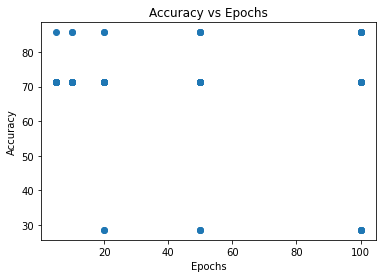

In [77]:
import matplotlib.pyplot as plt

# Example structure to store results
results = []

for lr in lr_array:
    for tr_size in tr_percent:
        size = round(len(instances_tr) * tr_size / 100)
        subset = instances_tr[:size]

        for epochs in num_epochs:
            weights = train_perceptron(subset, lr, epochs)
            accuracy = get_accuracy(weights, instances_te)

            results.append((tr_size, epochs, lr, accuracy))

# Example plot: Accuracy vs Epochs
epochs_vals = [r[1] for r in results]
acc_vals = [r[3] for r in results]

plt.scatter(epochs_vals, acc_vals)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.show()